# Detrending Methods in PASTS

Ce notebook illustre les différentes méthodes de detrending disponibles dans PASTS, appliquées au dataset **Corporación Favorita**.

On va :
1. Charger et préparer les données Favorita (store-level)
2. Visualiser toutes les méthodes de detrending sur un même signal
3. Comparer les composantes trend extraites vs le signal original
4. Utiliser une décomposition + modèle pour faire du forecast

In [ ]:
import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt

from pasts.signal import Signal
from pasts.components.trend import (
    Differencing,
    HPFilterTrend,
    HighPassFilterTrend,
    MovingAverageTrend,
    STLTrend,
)

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Chargement des données Favorita

In [2]:
DATA_DIR = os.path.join("..", "data", "favorita-grocery-sales-forecasting")
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
ITEMS_PATH = os.path.join(DATA_DIR, "items.csv")
STORES_PATH = os.path.join(DATA_DIR, "stores.csv")

dtypes = {
    "id": "int32",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "unit_sales": "float32",
    "onpromotion": "object",
}
train = pd.read_csv(TRAIN_PATH, dtype=dtypes, parse_dates=["date"], nrows=10_000_000)
train["unit_sales"] = train["unit_sales"].clip(lower=0)

items = pd.read_csv(ITEMS_PATH)
stores = pd.read_csv(STORES_PATH)
train = train.merge(items[["item_nbr", "family"]], on="item_nbr")
train = train.merge(stores[["store_nbr", "city", "state", "type"]], on="store_nbr")
print(f"Loaded {len(train):,} rows")

Loaded 10,000,000 rows


Shape: (233, 1)


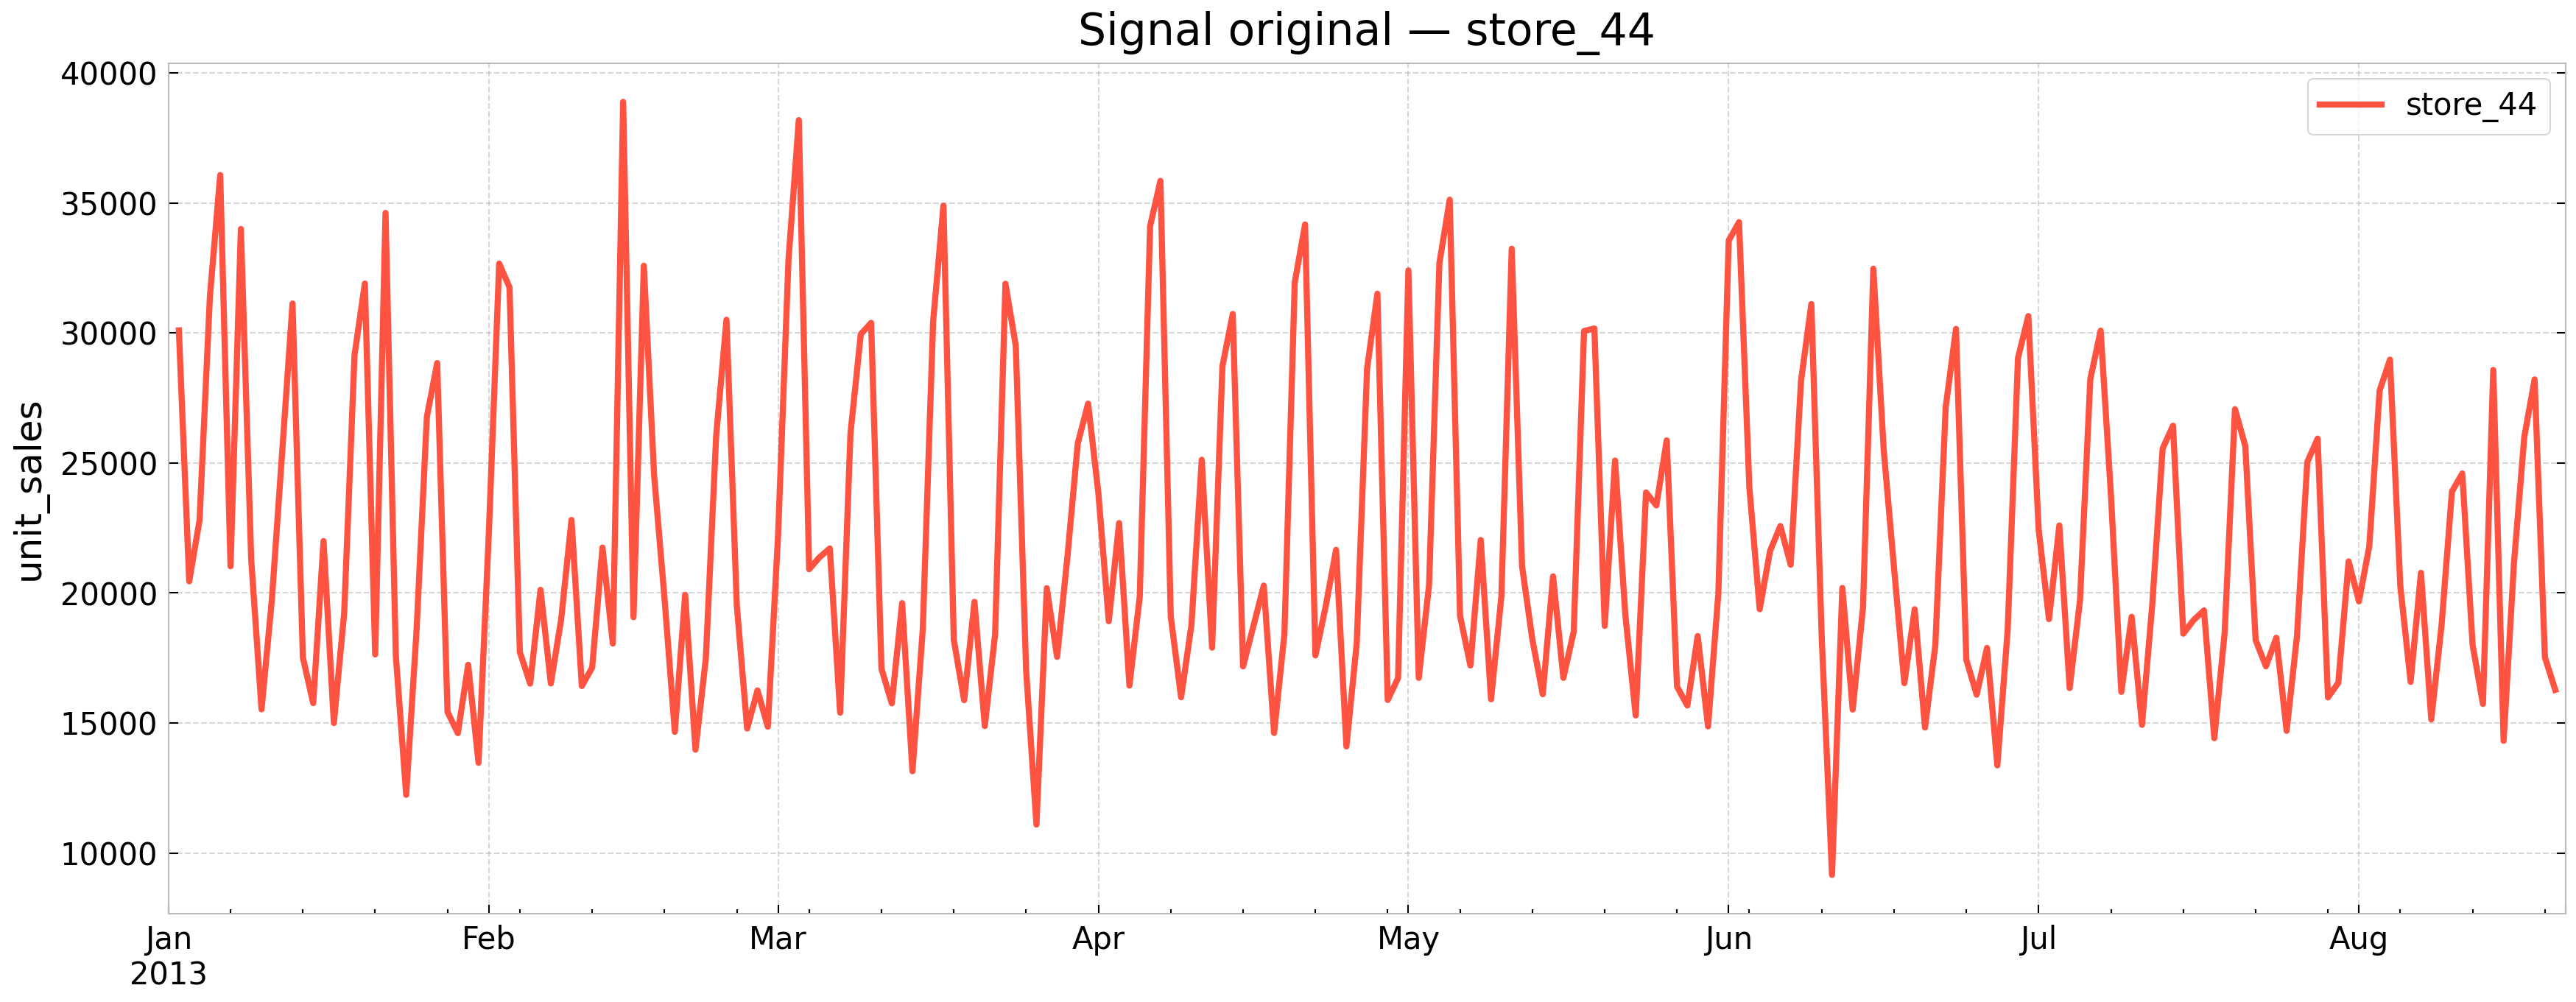

In [3]:
# Agréger au niveau store (daily)
df_store = (
    train.groupby(["date", "store_nbr"])["unit_sales"]
    .sum()
    .unstack("store_nbr")
    .sort_index()
)
df_store.columns = [f"store_{c}" for c in df_store.columns]

# Reindex avec un DatetimeIndex complet
full_idx = pd.date_range(df_store.index.min(), df_store.index.max(), freq="D")
df_store = df_store.reindex(full_idx, fill_value=0)

# Prendre un seul store pour la visualisation
col = "store_44"
df_uni = df_store[[col]].copy()

print(f"Shape: {df_uni.shape}")
df_uni.plot(title=f"Signal original — {col}")
plt.ylabel("unit_sales")
plt.show()

## 2. Comparaison des méthodes de detrending

On applique chaque méthode sur le même signal et on visualise :
- la **composante trend** extraite
- le **résidu** (signal - trend)

In [4]:
# Définir les méthodes de detrending
methods = {
    "Moving Average (w=90)": MovingAverageTrend(window=90),
    "HP Filter (λ=1e6)": HPFilterTrend(lamb=1e6),
    "STL (period=7)": STLTrend(period=7),
    "High-Pass (cutoff=0.01)": HighPassFilterTrend(cutoff=0.01, fs=1.0),
}

# Fit chaque méthode
fitted = {}
for name, model in methods.items():
    fitted[name] = model.fit(df_uni)

### 2a. Composantes trend extraites vs signal original

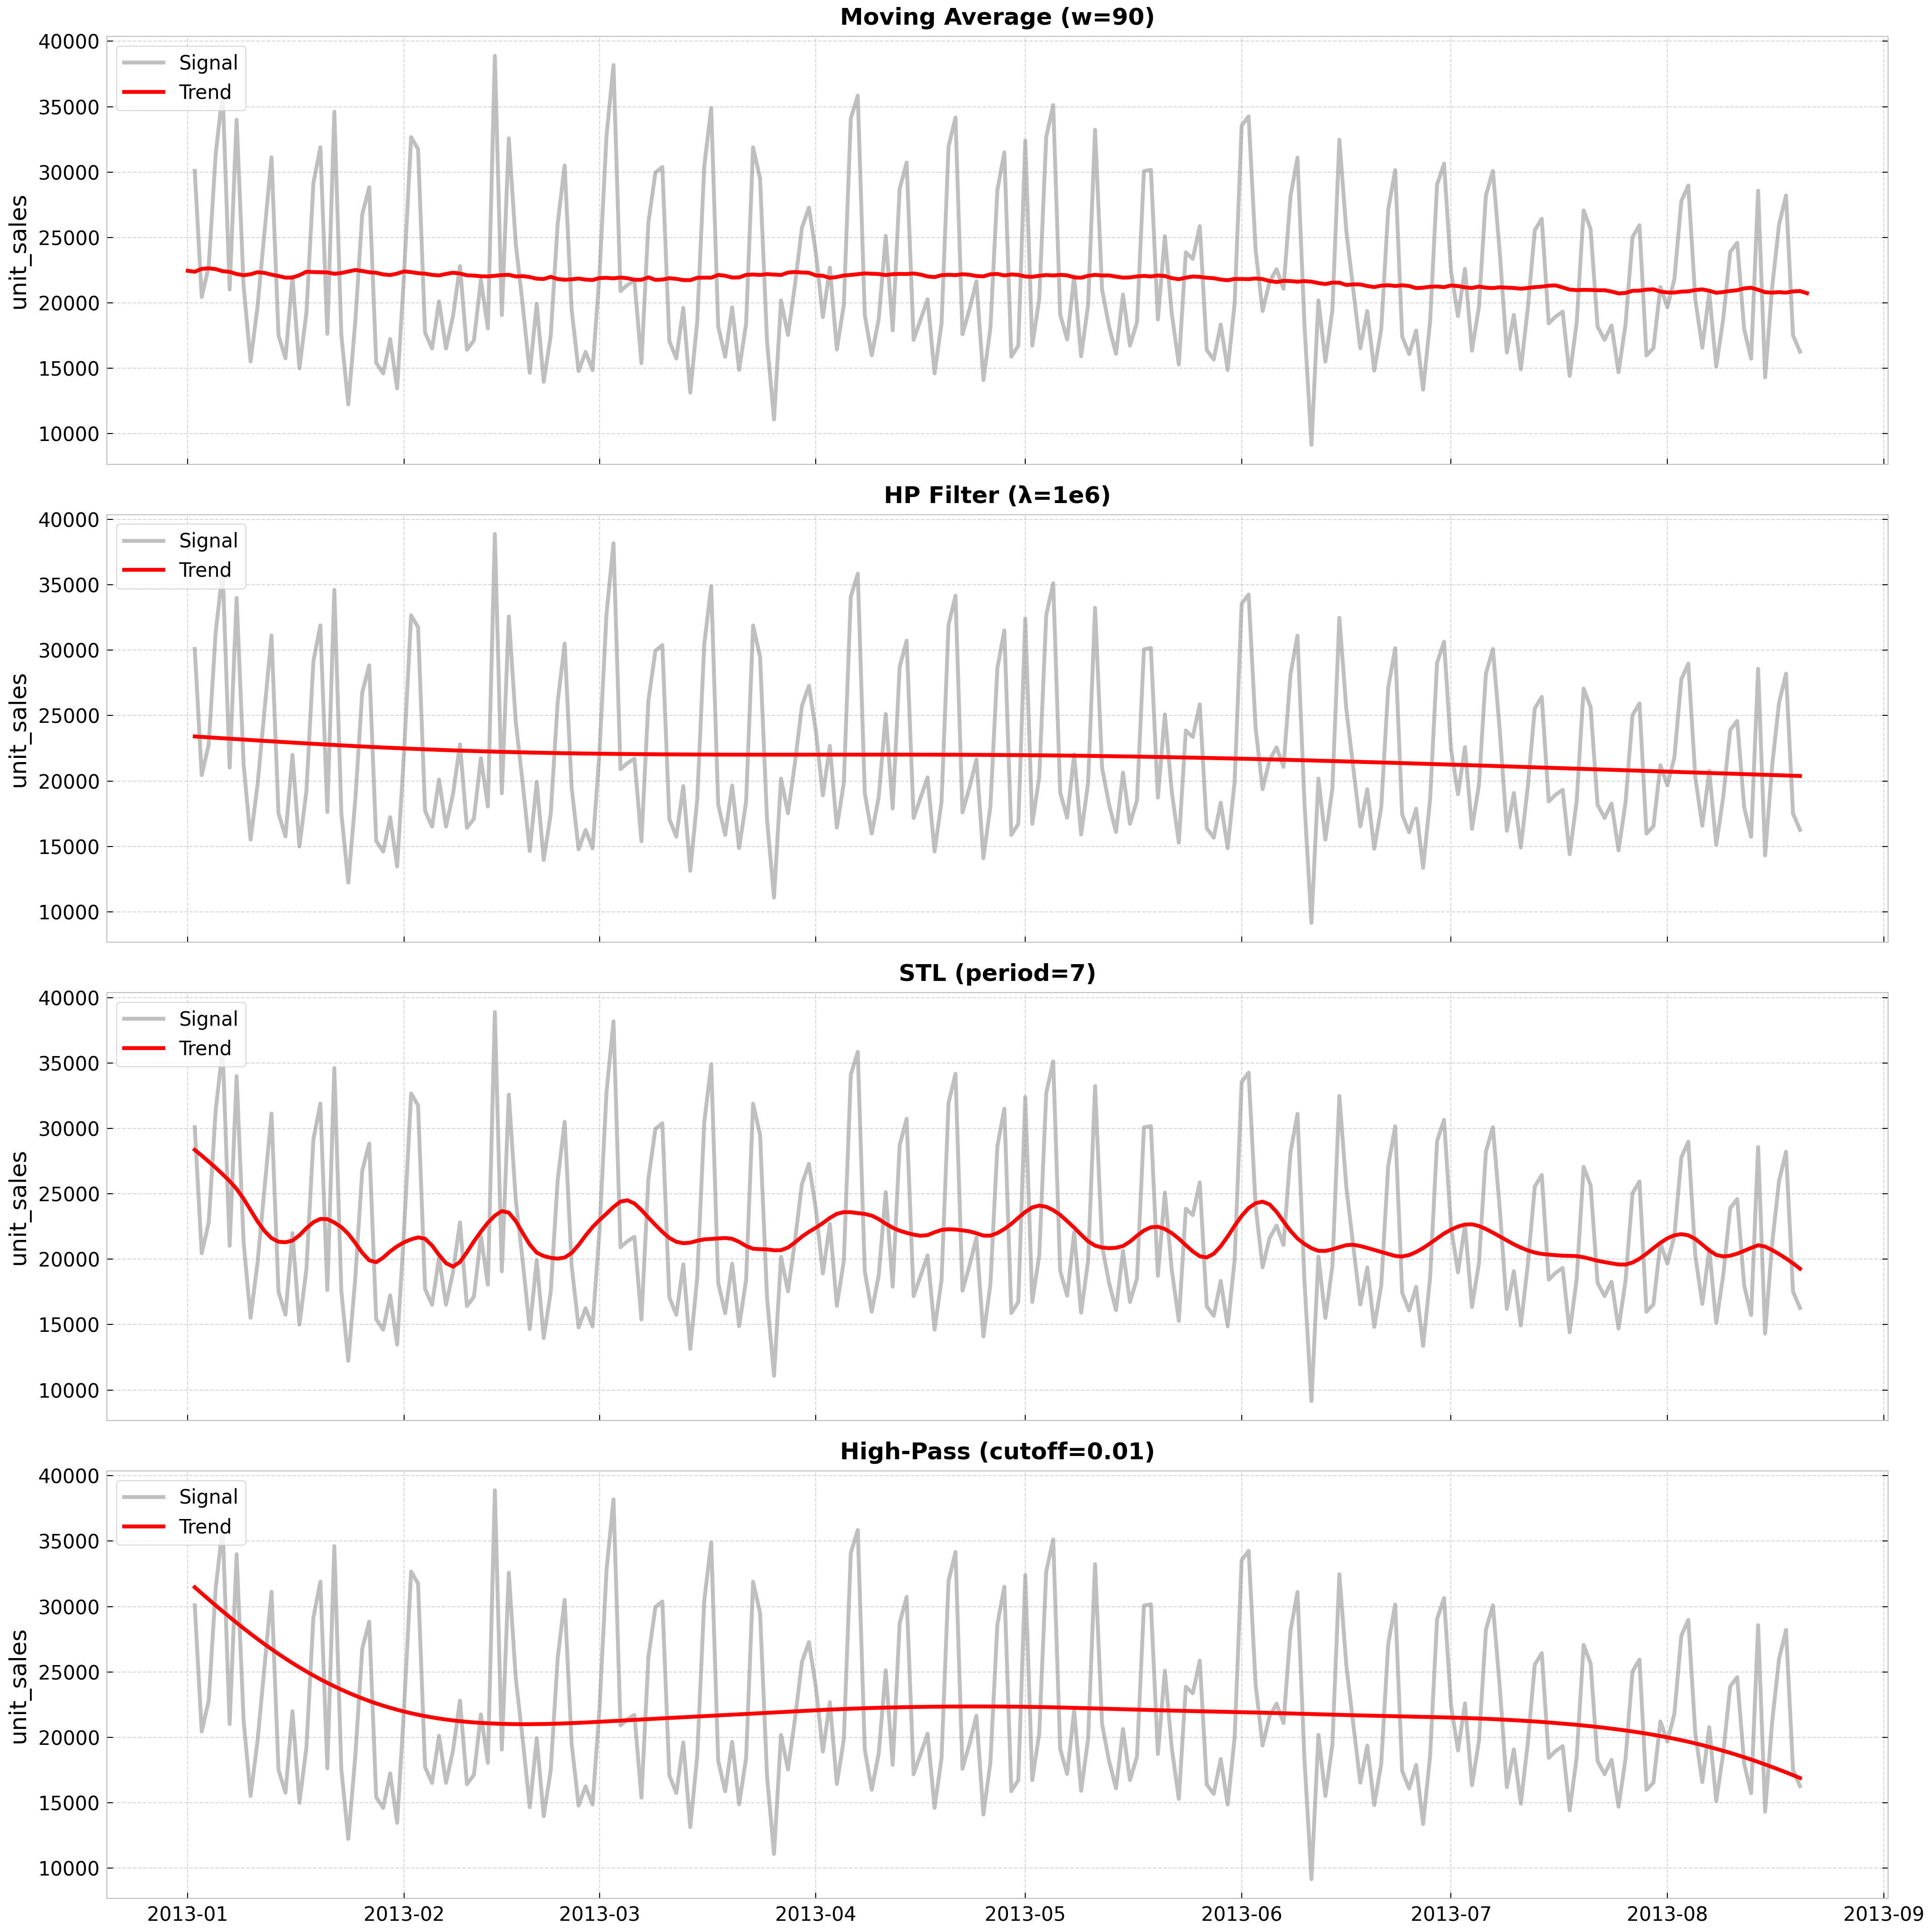

In [5]:
fig, axes = plt.subplots(len(fitted), 1, figsize=(14, 3.5 * len(fitted)), sharex=True)

for ax, (name, model) in zip(axes, fitted.items()):
    trend = model.reverse_transform(-len(df_uni))
    ax.plot(df_uni.index, df_uni[col].values, color="gray", alpha=0.5, label="Signal")
    ax.plot(trend.index, trend[col].values, color="red", linewidth=2, label="Trend")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(loc="upper left")
    ax.set_ylabel("unit_sales")

plt.tight_layout()
plt.show()

### 2b. Résidus après detrending

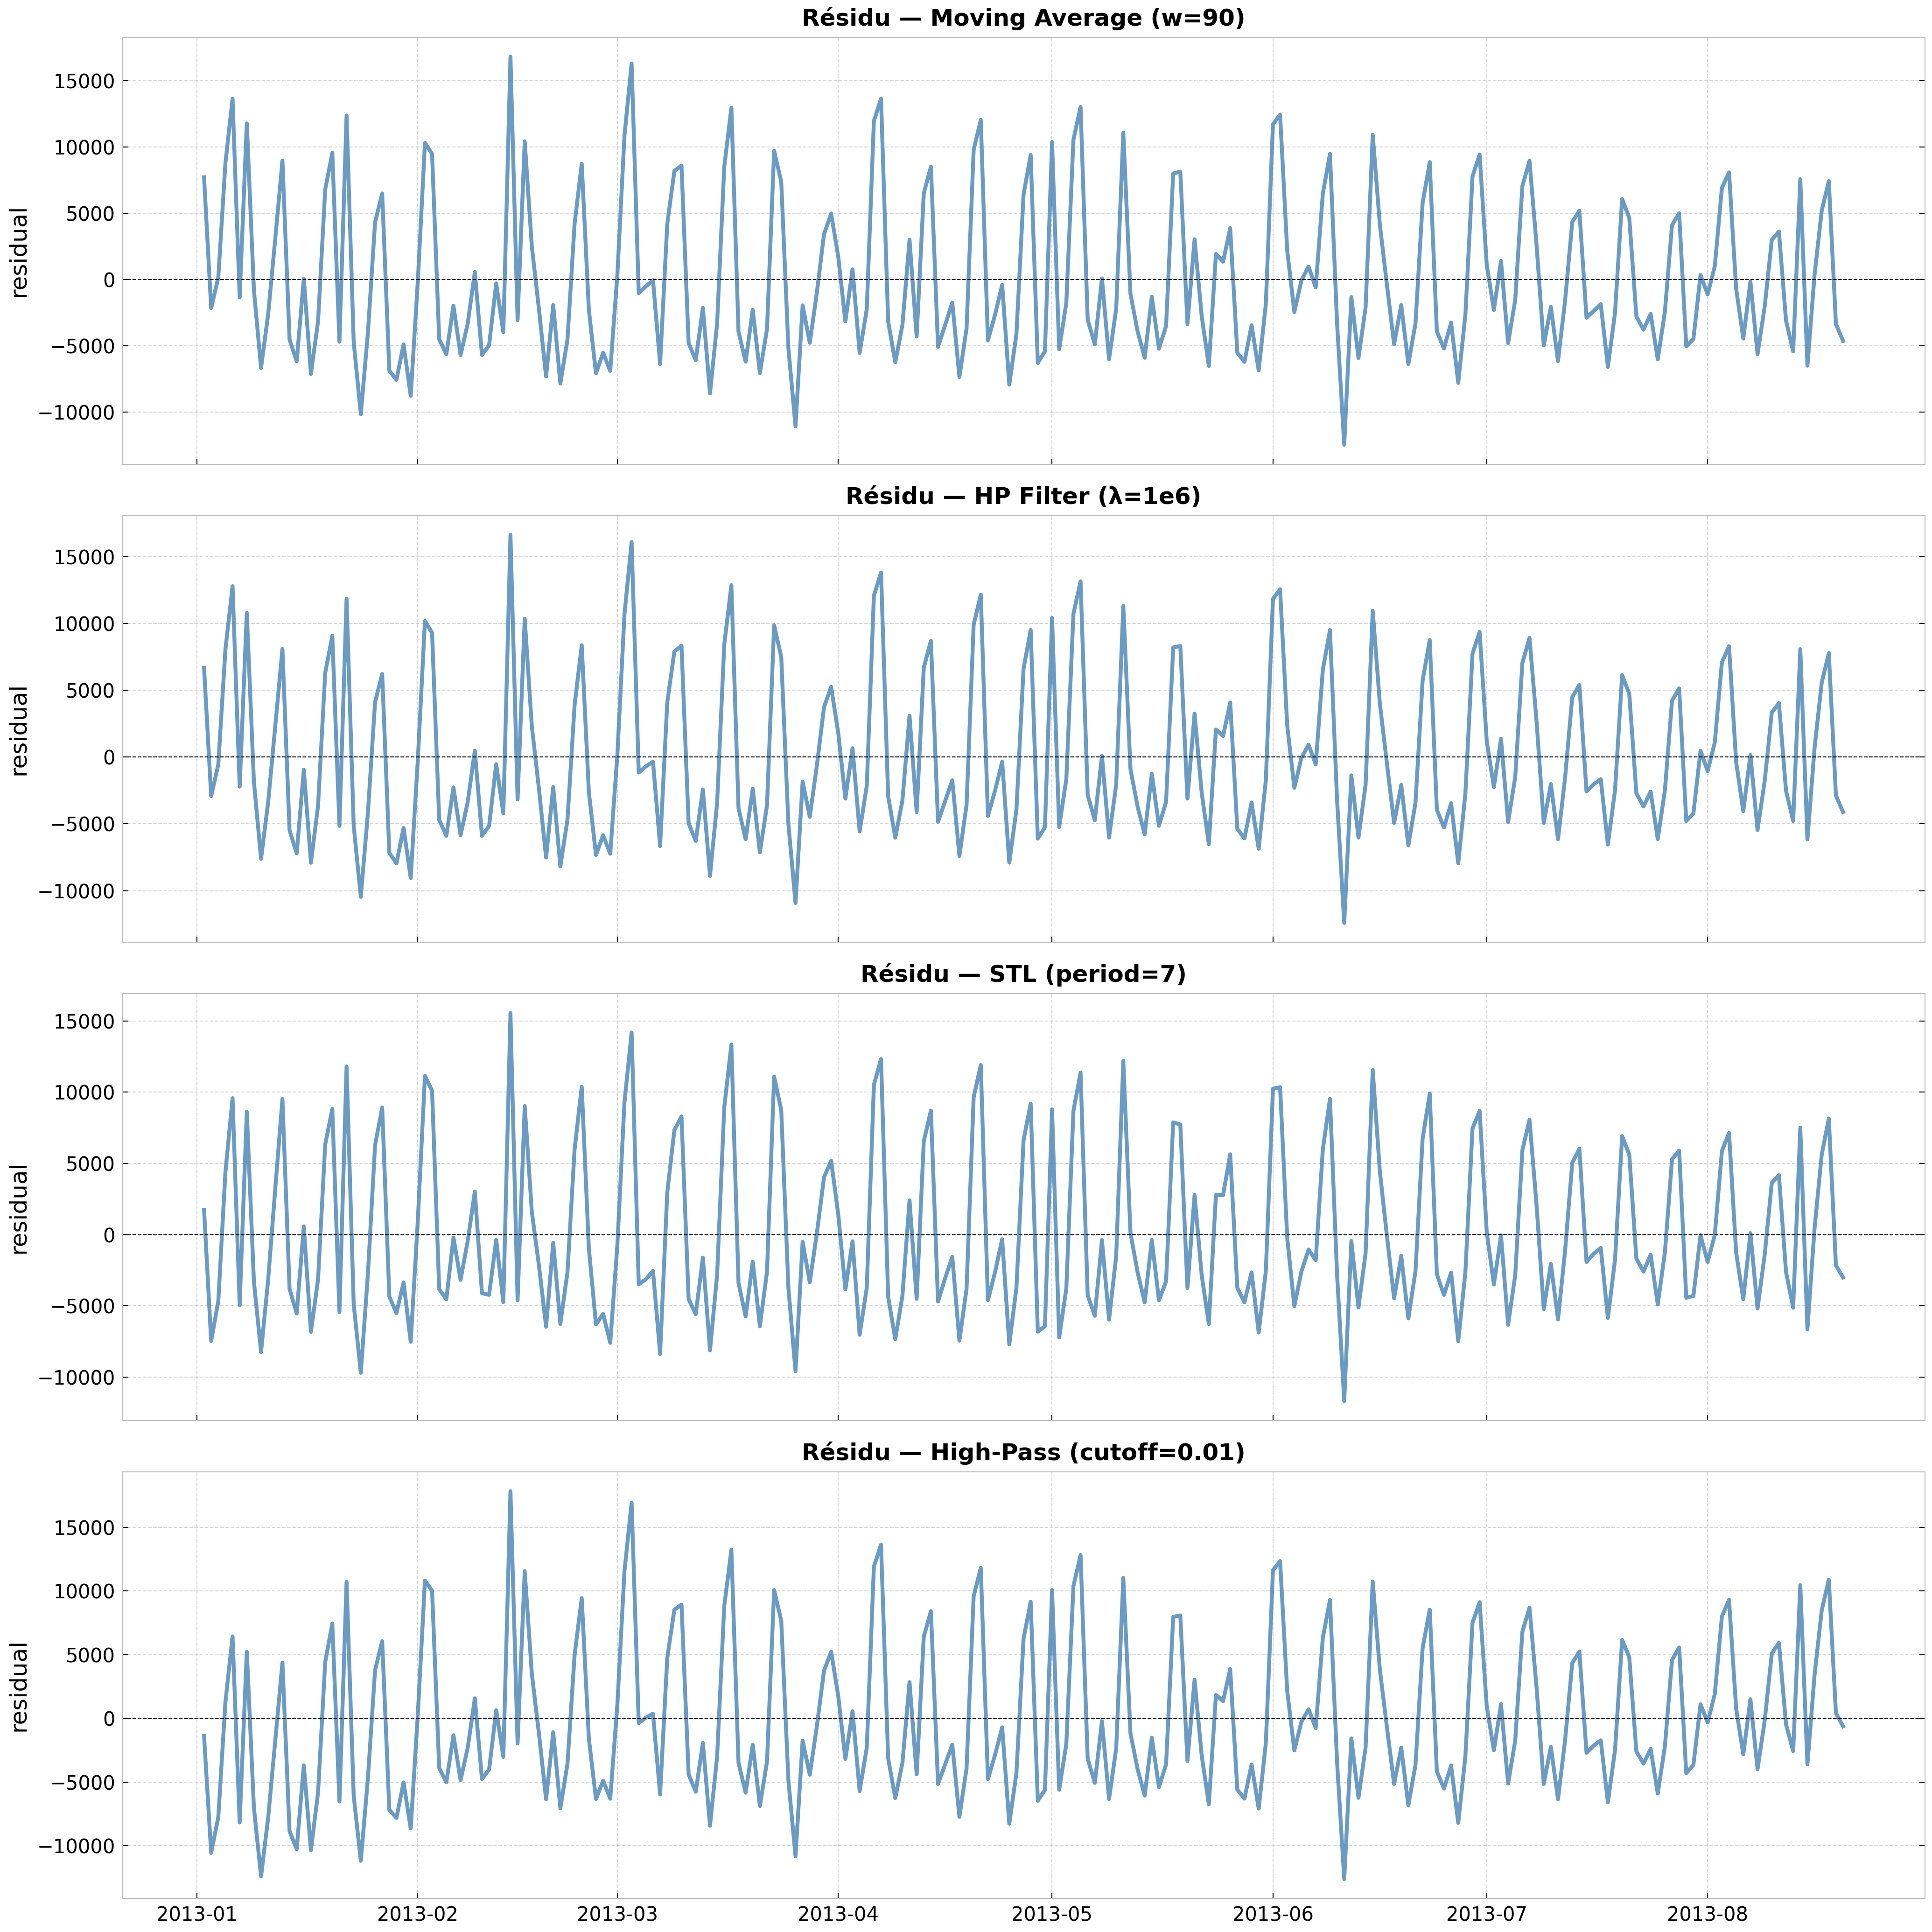

In [6]:
fig, axes = plt.subplots(len(fitted), 1, figsize=(14, 3.5 * len(fitted)), sharex=True)

for ax, (name, model) in zip(axes, fitted.items()):
    trend = model.reverse_transform(-len(df_uni))
    residual = df_uni[col].values - trend[col].values
    ax.plot(df_uni.index, residual, color="steelblue", alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(f"Résidu — {name}", fontsize=12, fontweight="bold")
    ax.set_ylabel("residual")

plt.tight_layout()
plt.show()

### 2c. Differencing (transform-based)

Le differencing s'utilise différemment : c'est une transformation via `DataCube.apply()`, pas une composante soustraite.

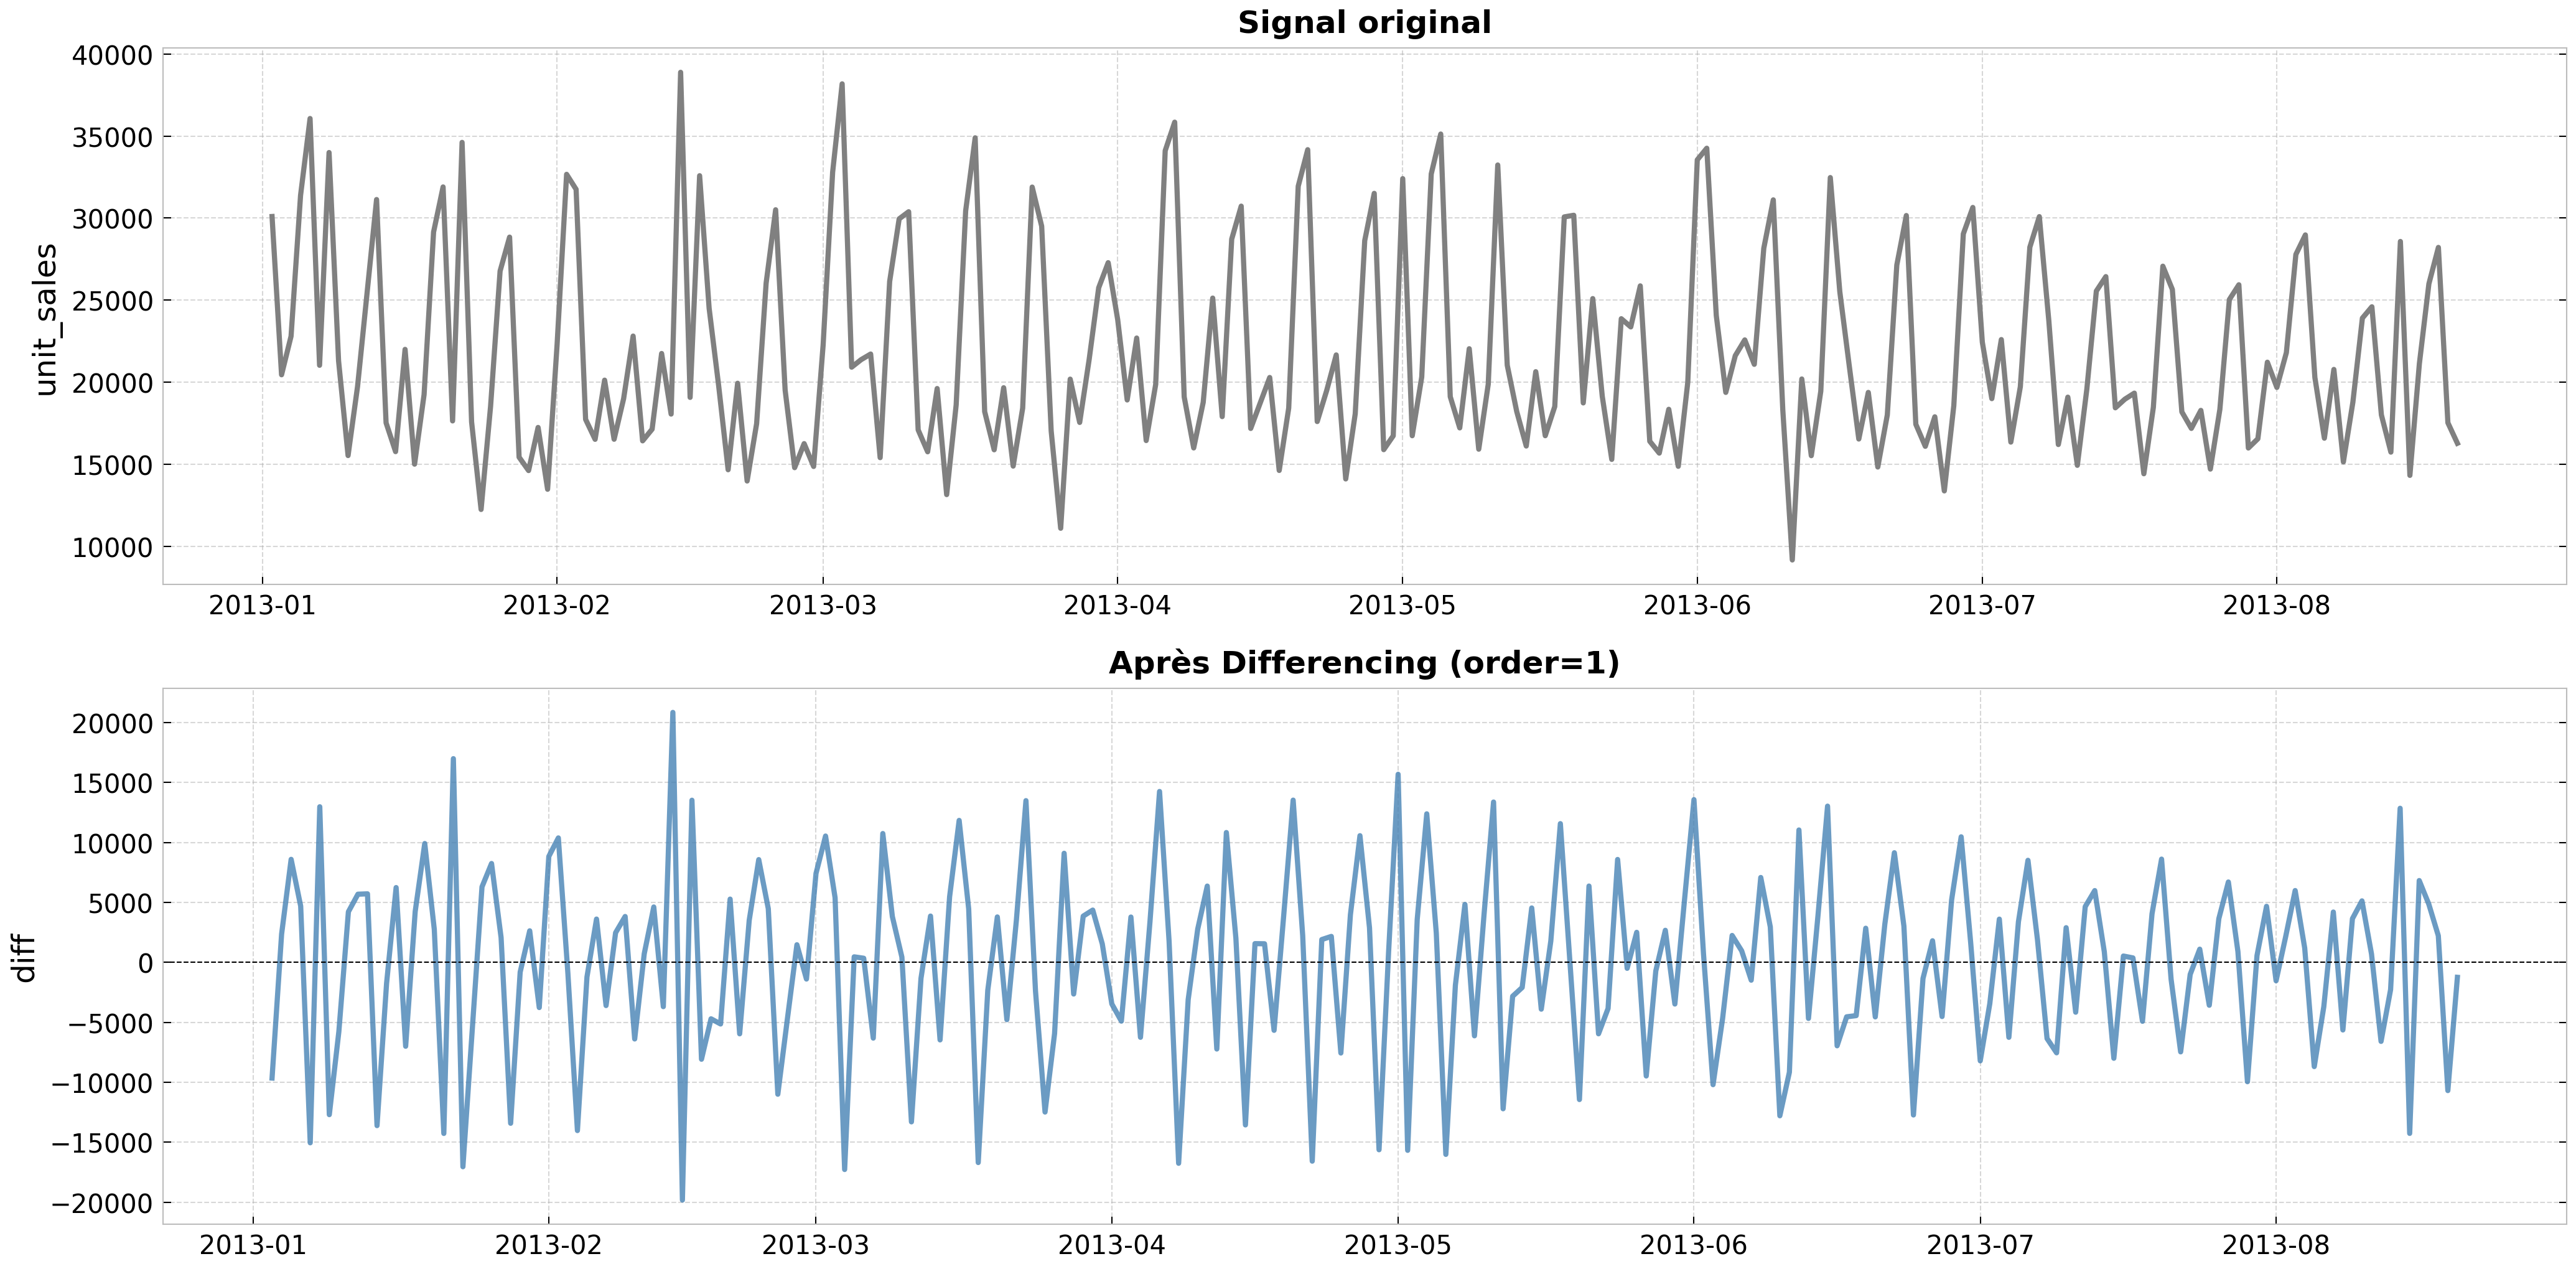

In [7]:
diff = Differencing(order=1).fit(df_uni)
differenced = diff.forward(df_uni)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(df_uni.index, df_uni[col].values, color="gray")
axes[0].set_title("Signal original", fontsize=12, fontweight="bold")
axes[0].set_ylabel("unit_sales")

axes[1].plot(differenced.index, differenced[col].values, color="steelblue", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("Après Differencing (order=1)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("diff")

plt.tight_layout()
plt.show()

### 2d. Toutes les trends superposées

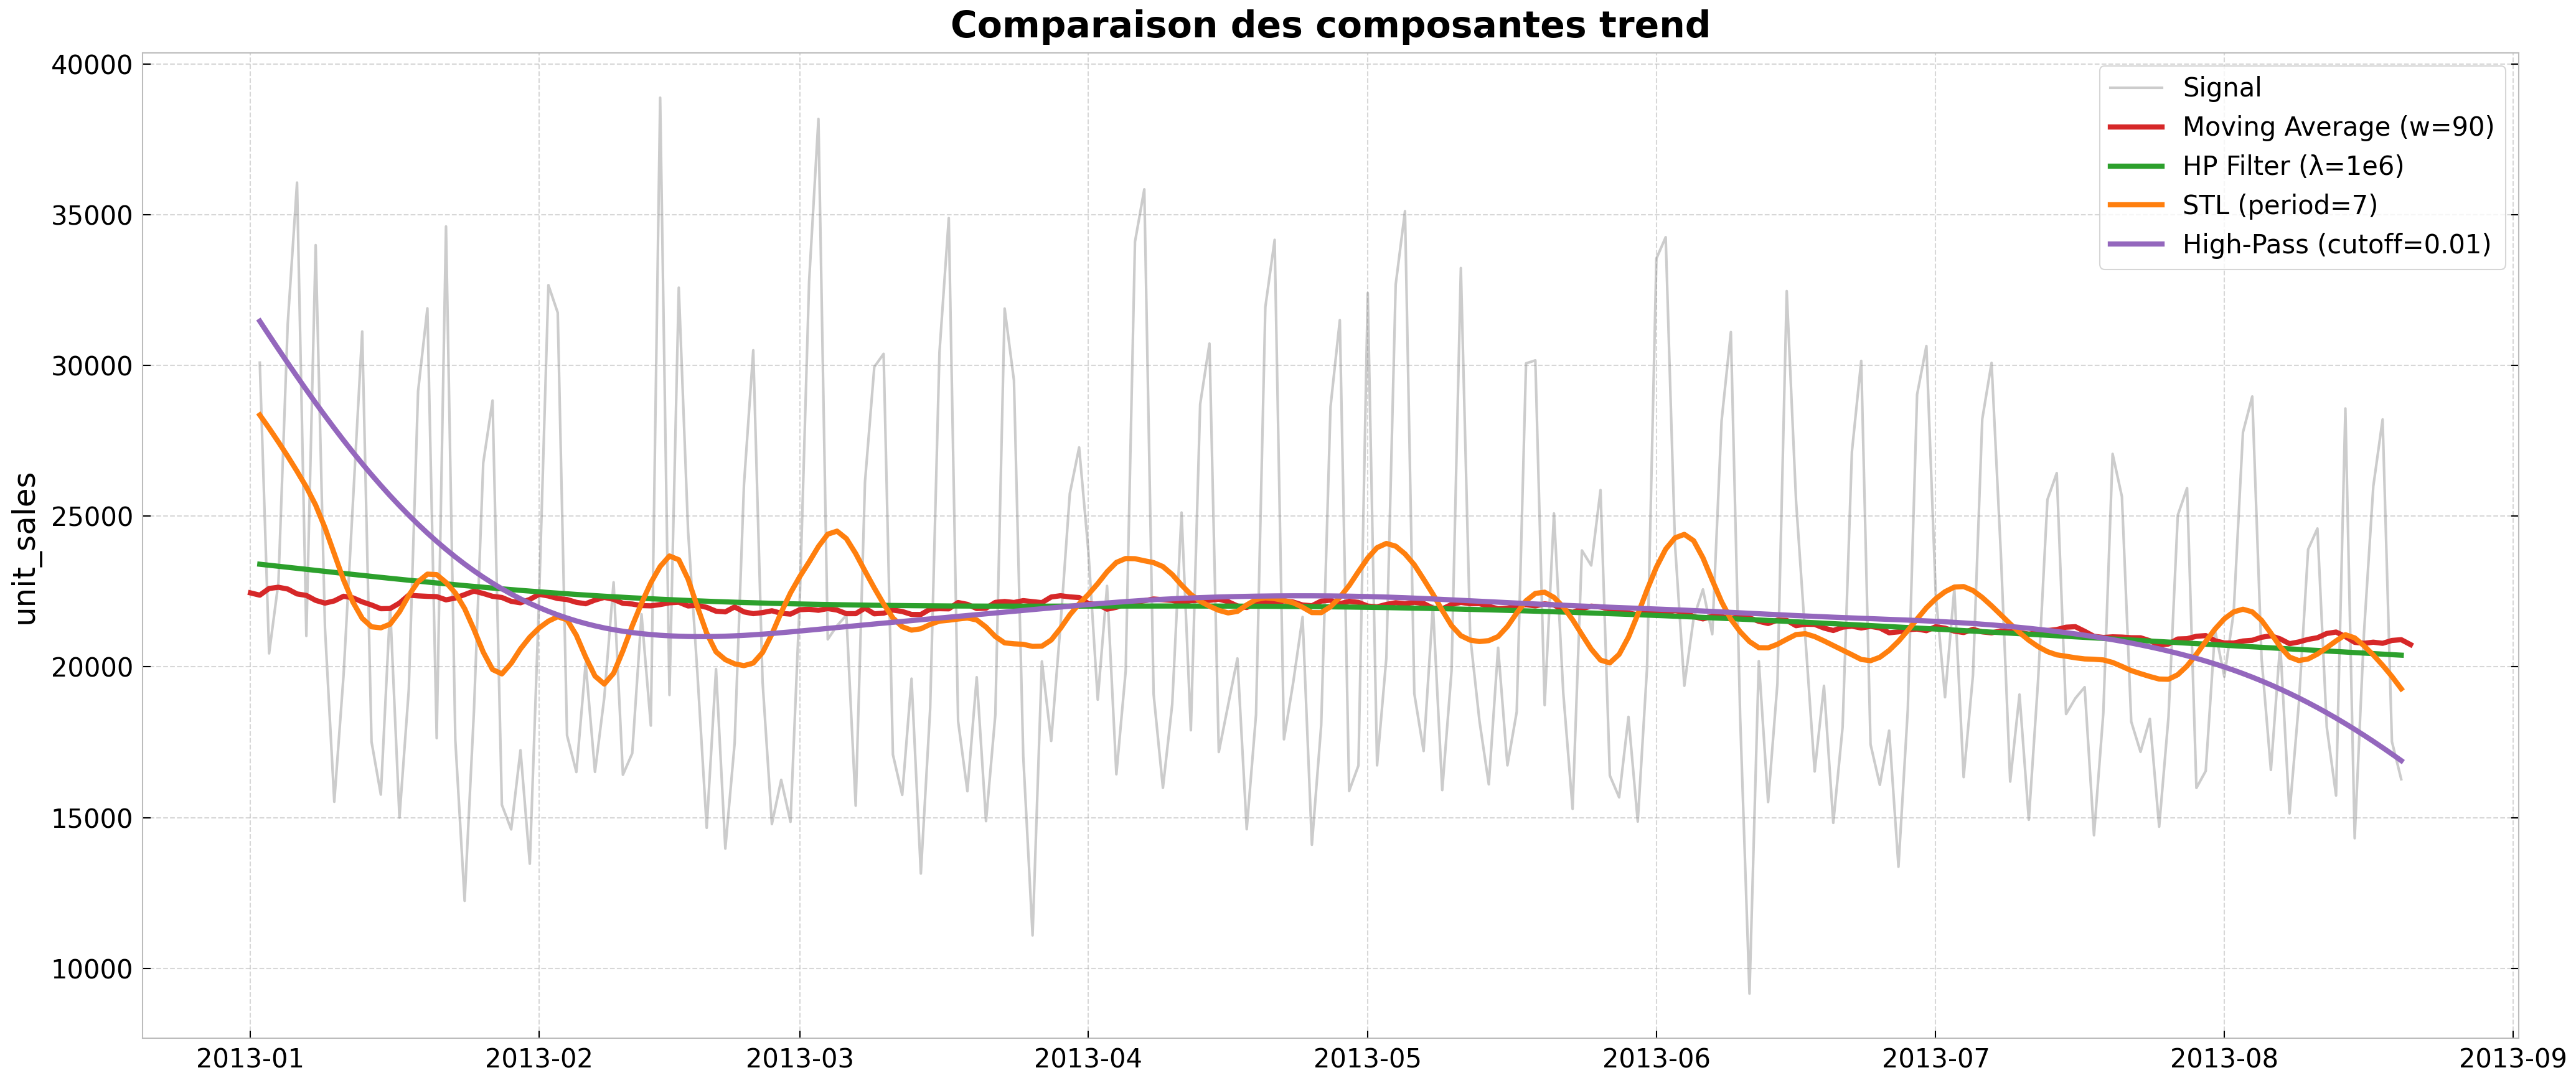

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_uni.index, df_uni[col].values, color="gray", alpha=0.4, linewidth=1, label="Signal")

colors_map = ["#d62728", "#2ca02c", "#ff7f0e", "#9467bd", "#1f77b4"]
for (name, model), c in zip(fitted.items(), colors_map):
    trend = model.reverse_transform(-len(df_uni))
    ax.plot(trend.index, trend[col].values, color=c, linewidth=2, label=name)

ax.set_title("Comparaison des composantes trend", fontsize=14, fontweight="bold")
ax.set_ylabel("unit_sales")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Multivarié — vérification sur plusieurs stores

Shape multivarié: (233, 3)


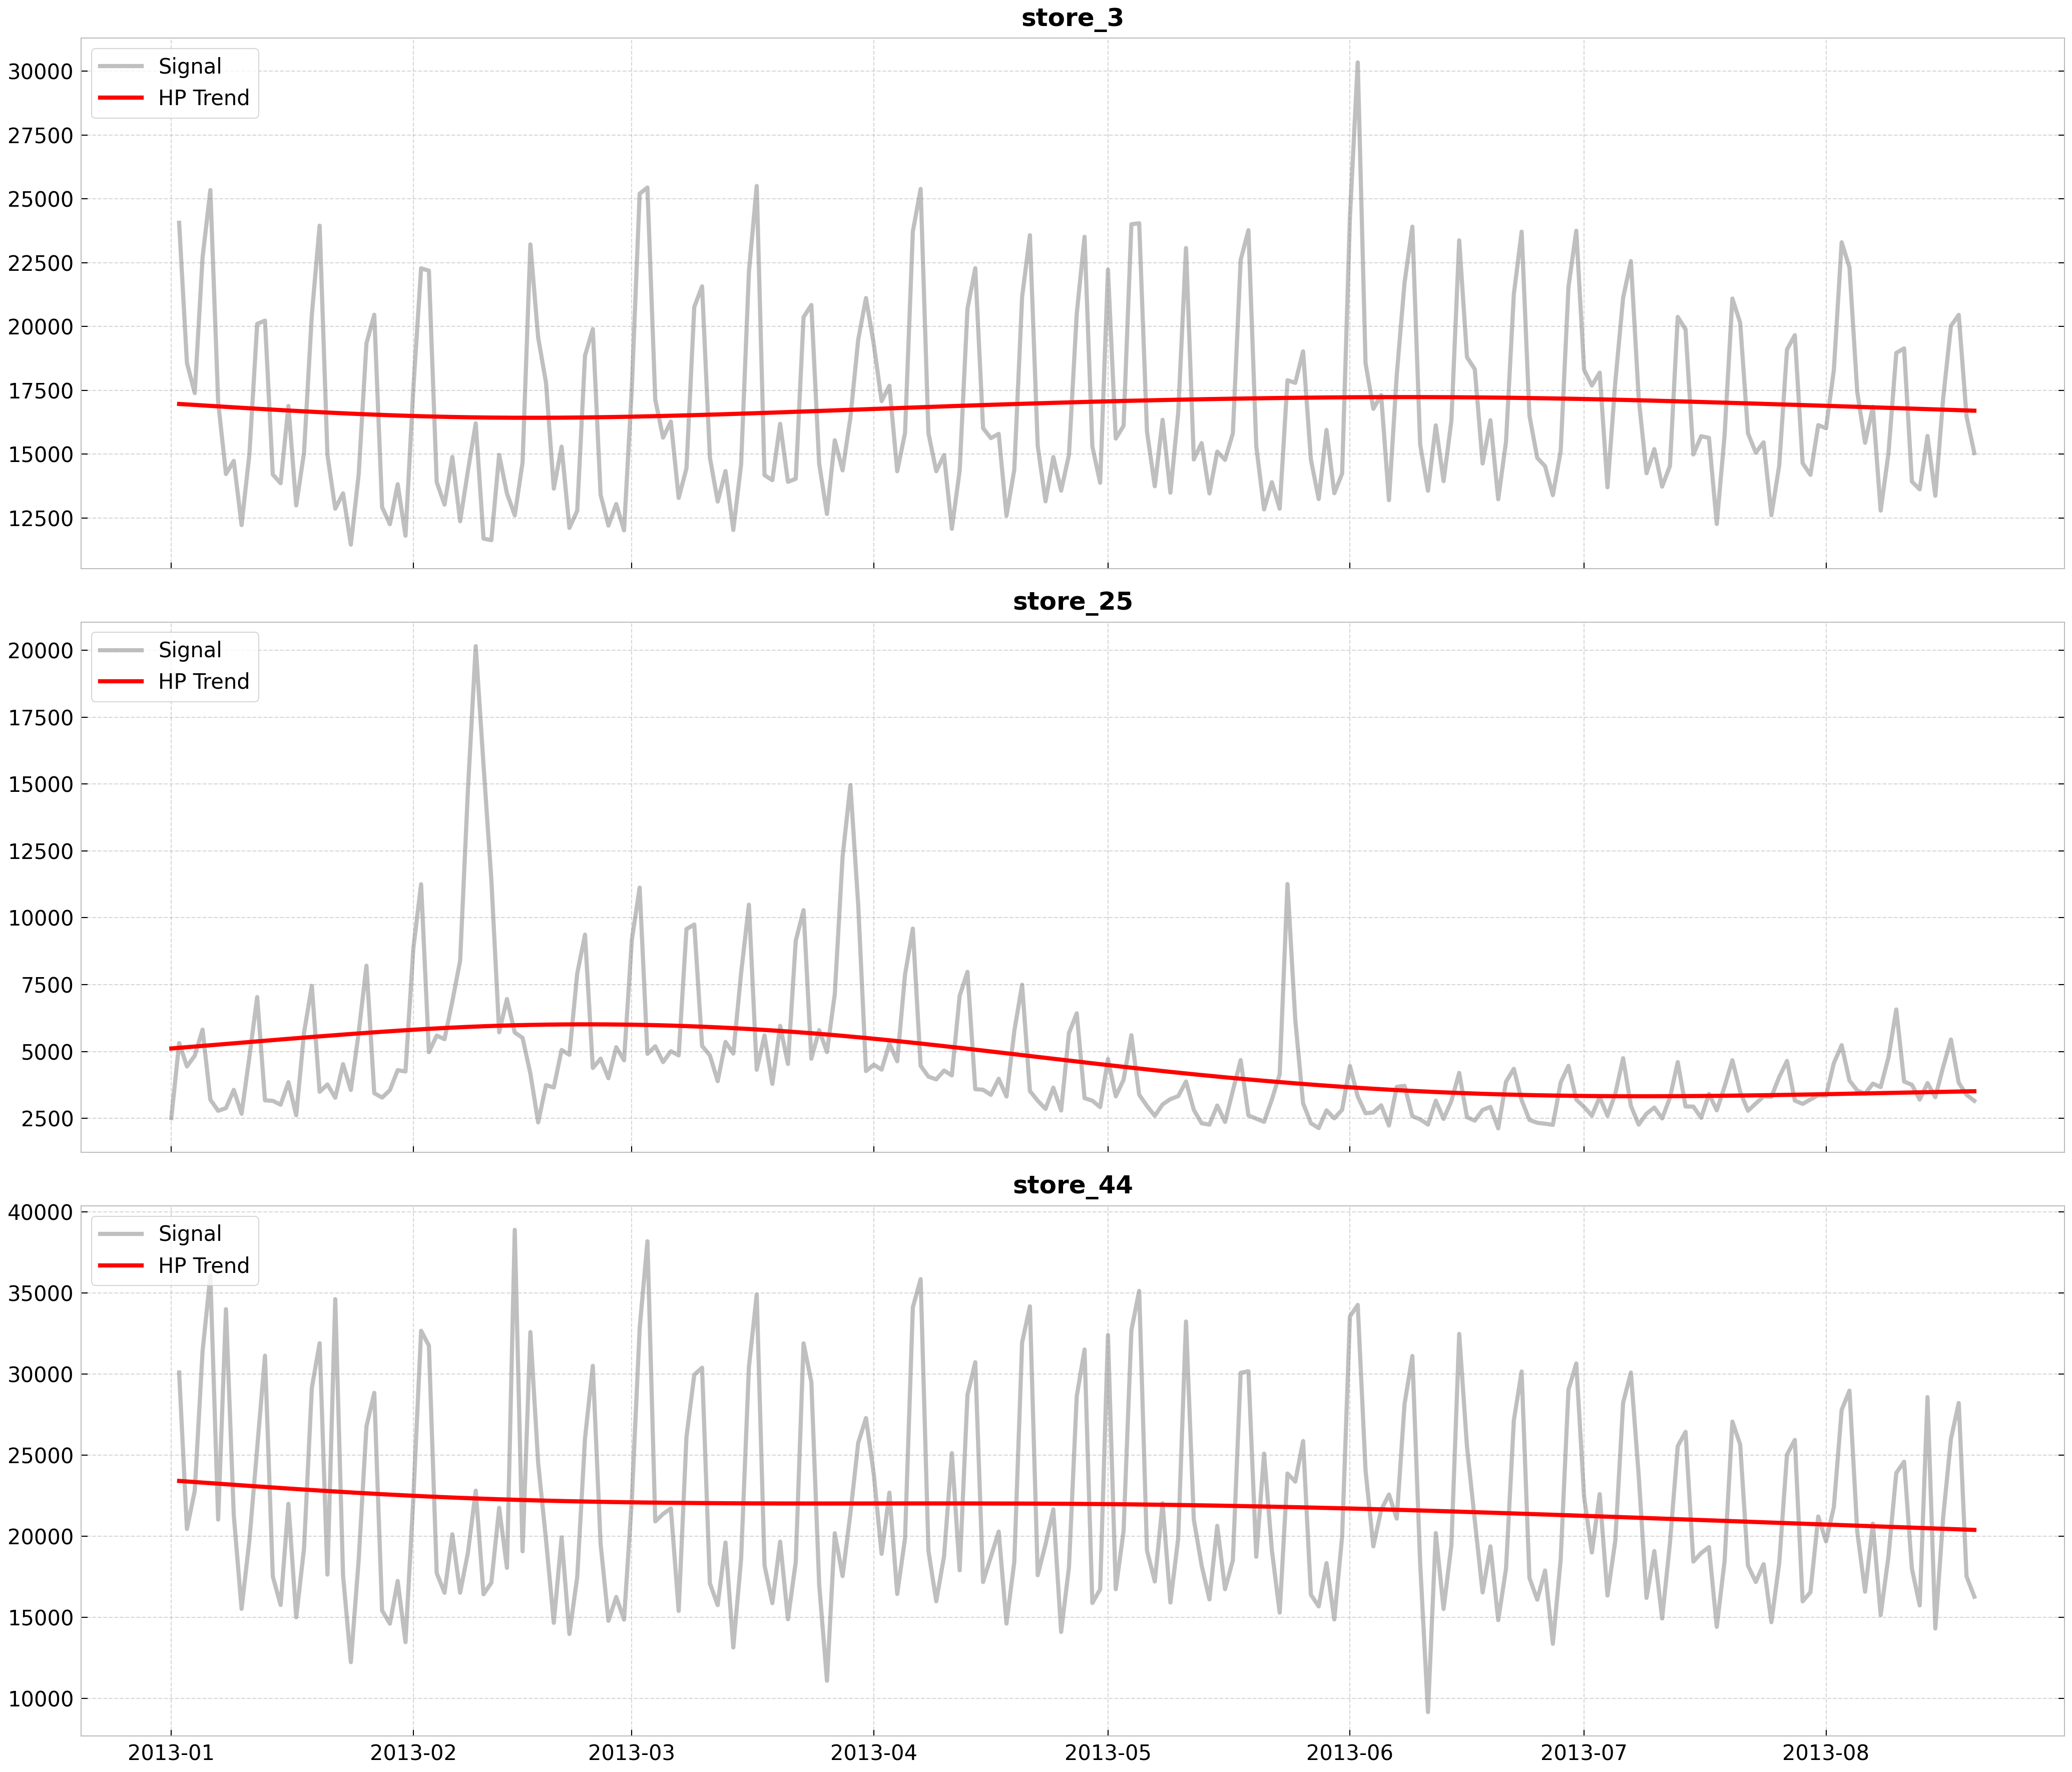

In [9]:
stores_cols = ["store_3", "store_25", "store_44"]
stores_cols = [s for s in stores_cols if s in df_store.columns]
df_multi = df_store[stores_cols].copy()

print(f"Shape multivarié: {df_multi.shape}")

# HP Filter sur données multivariées
hp = HPFilterTrend(lamb=1e6).fit(df_multi)
trend_multi = hp.reverse_transform(-len(df_multi))

fig, axes = plt.subplots(len(stores_cols), 1, figsize=(14, 4 * len(stores_cols)), sharex=True)

for ax, s in zip(axes, stores_cols):
    ax.plot(df_multi.index, df_multi[s].values, color="gray", alpha=0.5, label="Signal")
    ax.plot(trend_multi.index, trend_multi[s].values, color="red", linewidth=2, label="HP Trend")
    ax.set_title(s, fontsize=12, fontweight="bold")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 4. Workflow complet : décomposition + modèle + forecast

Exemple avec HP Filter pour retirer le trend, puis ExponentialSmoothing sur le résidu.

In [ ]:
from darts.models import ExponentialSmoothing

# Signal univarié
signal = Signal(df_uni.copy())

# Validation split : derniers 60 jours en test
timestamp = str(df_uni.index[-1] - pd.Timedelta(days=60))[:10]
signal.validation_split(timestamp=timestamp)
print(f"Train: {signal.train_data.shape}, Test: {signal.test_data.shape}")

# Décomposition : retirer le trend HP
signal.decompose()
signal.residual -= HPFilterTrend(lamb=1e6).fit(signal.data)

print(f"Décomposition: {signal.decomposition}")
signal.plot()

In [11]:
# Appliquer un modèle
signal.apply_model(ExponentialSmoothing())

# Scores
signal.compute_scores(["rmse", "mae", "r2"])
print("Scores (unit-wise):")
print(signal.models["ExponentialSmoothing"]["scores"]["unit_wise"])

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
# Forecast
signal.forecast("ExponentialSmoothing", horizon=30)
signal.compute_conf_intervals(window_size=7)

signal.plot.predictions()
signal.plot.forecast()

## 5. Workflow avec Differencing + learn sur résidu

In [ ]:
signal2 = Signal(df_uni.copy())
signal2.decompose()

# Appliquer le differencing sur le résidu
diff = Differencing(order=1).fit(signal2.residual.data)
signal2.residual.apply(diff.forward, diff.inverse)

print(f"Décomposition: {signal2.decomposition}")
print(f"Résidu shape: {signal2.residual.data.shape}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axes[0].plot(signal2.data)
axes[0].set_title("Signal original")
axes[1].plot(signal2.residual.data)
axes[1].set_title("Résidu (après differencing order=1)")
plt.tight_layout()
plt.show()

In [ ]:
# Learn un modèle sur le résidu et forecast via la décomposition
signal2.residual.learn(ExponentialSmoothing())
signal2.forecast(horizon=30)

model_name = signal2.residual._learned_model.name
forecast_df = signal2.models[model_name]["forecast"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(signal2.data, color="gray", alpha=0.6, label="Signal original")
ax.plot(forecast_df, color="red", linewidth=2, label="Forecast (recomposé)")
ax.set_title("Forecast après Differencing + ExponentialSmoothing")
ax.legend()
plt.tight_layout()
plt.show()